# TODO 

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Config + Load Analysis Class</h1>

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 
_=pl.Config.set_tbl_cols(1000000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)


%load_ext autoreload 
%autoreload 2
    
import importlib

SecondOrderShapNetworkAnalyzer = getattr(
    importlib.import_module("2_second_order_shap_analysis"), 
    "SecondOrderShapNetworkAnalyzer"
)

analyzer = SecondOrderShapNetworkAnalyzer()

import yaml 

with open('./1_variable_config.yaml', 'r') as file:
    CONFIG = yaml.safe_load(file)


2026-01-14 19:18:29.822 | SUCCESS  | 2_second_order_shap_analysis:__post_init__:34 - Class initialized and loaded.


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Retrieve SHAP Metrics</h1>

In [ ]:
example = analyzer.retrieve_shap_values_for_metric(metric = "Signed-Local-SHAP-Mean-Bound-Only")
example.sample(20)

In [ ]:
for cell_line in CONFIG["CELL_LINES"]: 
    total_rows = example.filter(
        (pl.col("Cell Line") == cell_line) & 
        (pl.col("Column Type") == "interaction")
    ).height
    
    tmp = example.filter(
        (pl.col("Cell Line") == cell_line) & 
        (pl.col("Value - Signed-Local-SHAP-Mean-Bound-Only").abs() >= .0001) & 
        (pl.col("Column Type") == "interaction")
    )

    total_rows
    tmp.head()
    

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Interaction Heatmaps</h1>

In [ ]:
for source in CONFIG["PPI_SOURCES"]: 
    for highlight in CONFIG["PPI_TYPES"]: 
    
        HepG2_options = {
            "highlight": highlight,
            
            "figsize": (22, 10),
            'dpi': 600,
            'tick_fontsize': 2, 
            'title_fontsize': 20, 
            'cell_linewidth': 0.05, 
            'legend_titlesize': 15, 
            'label_padding': 5
        }
        
        analyzer.plot_side_by_side_heatmaps_for_min_1_ppi(
            cell_line = "HepG2", 
            ppi_source= source, 
            metric = 'Signed-Local-SHAP-Mean-Bound-Only',
            **HepG2_options
        )

In [ ]:
for source in CONFIG["PPI_SOURCES"]: 
    for highlight in CONFIG["PPI_TYPES"]: 
    
        K562_options = {
            "highlight": highlight,
            
            "figsize": (24, 11),
            'dpi': 600,
            'tick_fontsize': 1.5, 
            'title_fontsize': 20, 
            'cell_linewidth': 0.02, 
            'legend_titlesize': 15, 
            'label_padding': 5
        }
        
        analyzer.plot_side_by_side_heatmaps_for_min_1_ppi(
            cell_line = "K562", 
            ppi_source= source, 
            metric = 'Signed-Local-SHAP-Mean-Bound-Only',
            **K562_options
        )

<h1 style="color: teal; font-weight: bold; font-size: 48px;">PPI ROC/PRC Curves</h1>

In [ ]:
analyzer.plot_roc_and_prc_curves_for_metric(metric = 'Signed-Local-SHAP-Mean-Bound-Only')

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Actual PSI by Binding for All Position PPI-Only Interactions</h1>

In [ ]:
analyzer.plot_actual_psi_by_binding_for_PPI()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Distributions of PPI/Non-PPI Values</h1>

2026-01-14 21:15:26.611 | SUCCESS  | 2_second_order_shap_analysis:retrieve_shap_values_for_metric:690 - FROM CACHE: loading 'Signed-Local-SHAP-Mean-Bound-Only' values from '../outputs/SHAP_cache/averages/Signed-Local-SHAP-Mean-Bound-Only.tsv'...


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:4.510e-03 U_stat=2.866e+04


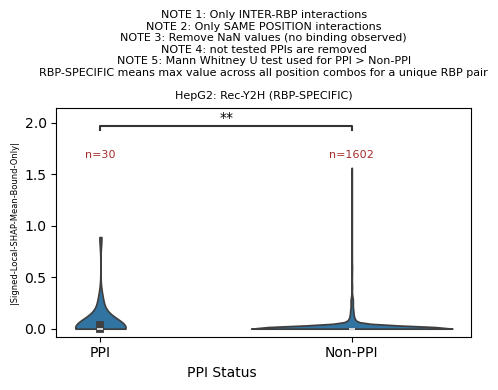

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:2.052e-02 U_stat=4.319e+05


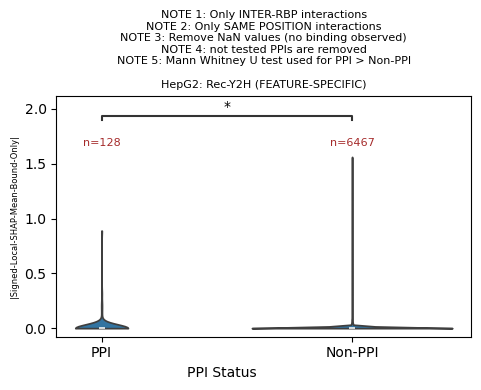

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:6.345e-04 U_stat=4.504e+04


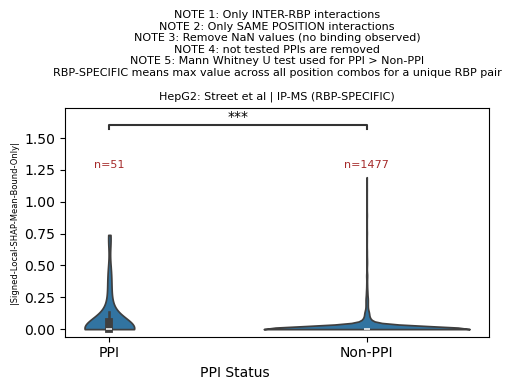

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:8.552e-05 U_stat=7.850e+05


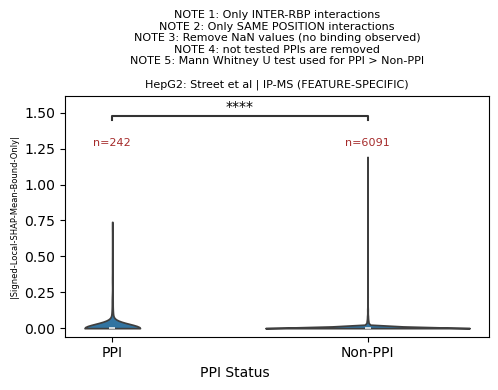

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:2.226e-02 U_stat=1.387e+04


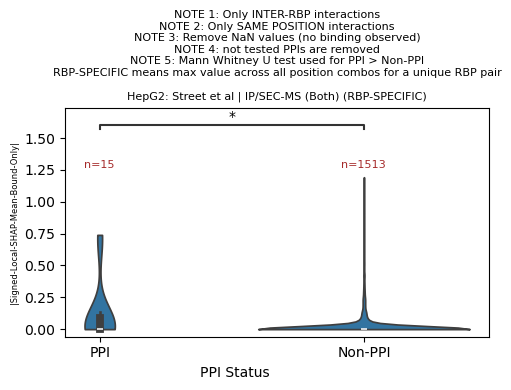

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:8.891e-02 U_stat=2.318e+05


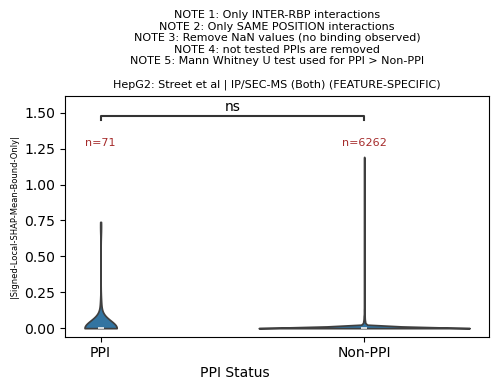

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:1.331e-02 U_stat=5.836e+04


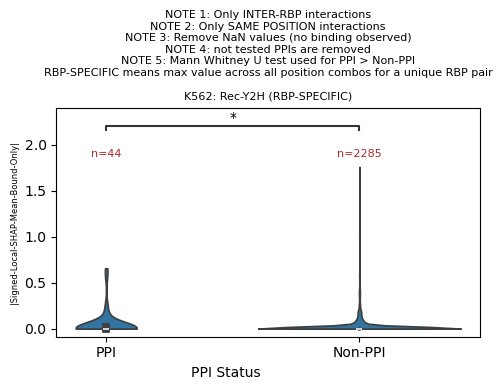

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:4.623e-02 U_stat=8.863e+05


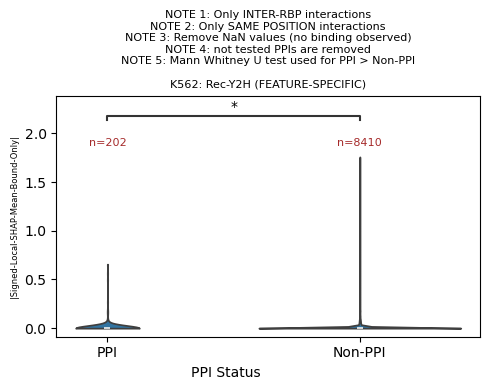

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:7.448e-04 U_stat=1.217e+05


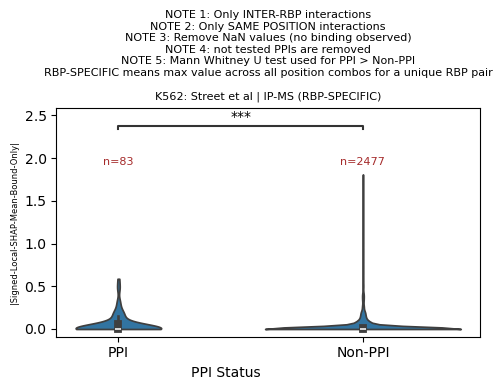

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:1.242e-04 U_stat=2.056e+06


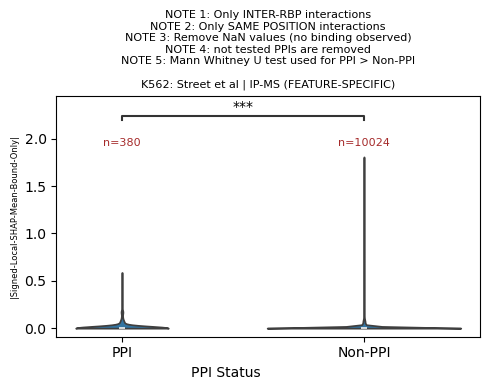

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:5.481e-02 U_stat=2.874e+04


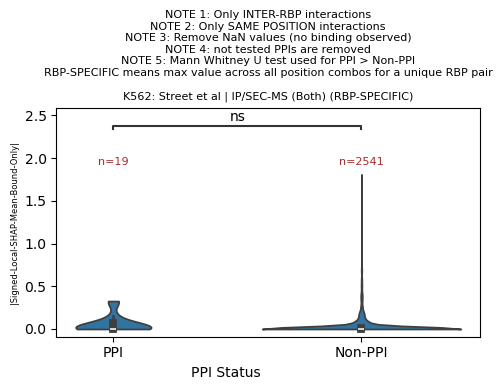

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PPI vs. Non-PPI: Mann-Whitney-Wilcoxon test greater, P_val:2.379e-02 U_stat=4.833e+05


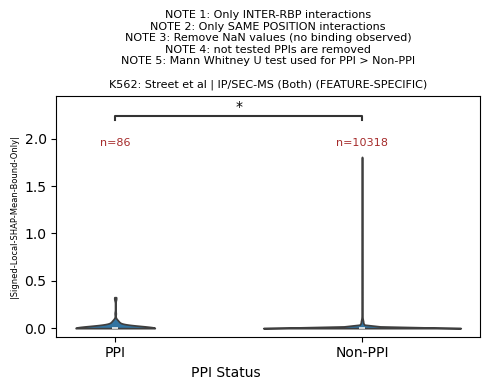

In [101]:
analyzer.ppi_vs_non_ppi_shap_value_distributions(metric = "Signed-Local-SHAP-Mean-Bound-Only")

In [ ]:
plots_summary = pl.read_csv("../outputs/figures/actual_PSI_by_binding/summary_table_for_PPI_ONLY_actual_psi_by_binding.tsv", separator="\t")
plots_summary = plots_summary.rename({"Interaction Column": "Column"})

plots_summary.head(3)

In [ ]:
averages = pl.read_csv("../outputs/SHAP_cache/averages/Signed-Local-SHAP-Mean-Bound-Only.tsv", separator="\t")
averages.head()

In [ ]:
df = averages.join(
    plots_summary, 
    how='left', 
    on=["Cell Line", "Column"], 
    validate = "1:1", 
    maintain_order="left"
)

df.head()

In [ ]:
df.filter(
    pl.col("Column Type") == "main"
).with_columns(
    pl.all().is_null()
).sum_horizontal().unique().item() == 18

In [ ]:
df.filter(
    pl.col("Rec-Y2H/Street et al. IP-MS (Union)") == "None"
).with_columns(
    pl.all().is_null()
).sum_horizontal().unique().item() == 14
    

In [ ]:
df.filter(
    (pl.col("Rec-Y2H/Street et al. IP-MS (Union)") != "None") & 
    (pl.col("Value - Signed-Local-SHAP-Mean-Bound-Only") != float('nan'))
).with_columns(
    pl.all().is_null()
).sum_horizontal().value_counts()

In [ ]:
df.filter(
    (pl.col("Rec-Y2H/Street et al. IP-MS (Union)").str.ends_with("-Position")) 
    # (pl.col("Value - Signed-Local-SHAP-Mean-Bound-Only") == float('nan'))
).with_columns(
    pl.all().is_null()
).sum_horizontal().value_counts()

In [ ]:
df.head()

In [ ]:
df.write_csv("../../../../../tables_and_figures_while_yogi_away_in_India_December_2025/6_second_order_SHAP/MASTER_TABLE.tsv", separator="\t")